In [3]:
library(Seurat)

In [4]:
library(tidyverse)

In [5]:
data <-readRDS('GCA_obj_subset_excludecells3.Rdata')

In [6]:
lownames <- readRDS('lownames.rds')
highnames <- readRDS('highnames.rds')

In [7]:
ploidy <- read.table('/disk1/pengweixing/esophageal/26.copyKat/test_copykat_prediction.txt',header=T)
rownames(ploidy) <- ploidy$cell.names

In [6]:
high_cnv <- readRDS('infercnv_high2/high_cnv.names.Rds')

In [8]:
low_cnv <- readRDS('infercnv_high2/low_cnv.names.Rds')

In [10]:
data@meta.data  %>% filter(celltype=='Epi_tumor')  %>% rownames()  %>% data[,.]  -> data_epi

In [227]:
data_epi@meta.data  %>% mutate(erbb2 = ifelse(sample %in% highnames,'High',"Low"))  %>% count(erbb2)

erbb2,n
<chr>,<int>
High,3375
Low,1756


In [14]:
data_epi@meta.data  %>% rownames()  %>% ploidy[.,'copykat.pred' ]  -> data_epi@meta.data$ploidy

In [17]:
data_epi@meta.data  %>% mutate(group = ifelse(sample %in% highnames,'high','low'))  %>% count(ploidy,group)

ploidy,group,n
<chr>,<chr>,<int>
aneuploid,high,2517
aneuploid,low,997
diploid,high,739
diploid,low,508
not.defined,high,119
not.defined,low,251


In [18]:
data_epi@meta.data   %>% mutate(group = ifelse(sample %in% highnames,'high','low')) %>% count(group)

group,n
<chr>,<int>
high,3375
low,1756


In [26]:
matrix(c(2517,3375-2517,997,1756-997),nrow=2)  

2517,997
858,759


In [19]:
2517/3375

[1] 0.7457778

In [20]:
997/1756

[1] 0.5677677

In [78]:
data_epi@meta.data  %>% filter(sample  %in% highnames)  %>% rownames()  %>% data_epi[,.] -> data_epi_high

In [ ]:
data_epi_high@meta.data  %>% rownames()  %>% ploidy[.,'copykat.pred' ]  -> data_epi_high@meta.data$ploidy

In [ ]:
data_epi_high@meta.data  %>%  count(ploidy)

In [157]:
data_epi_high@meta.data$cnv = 'non'

In [158]:
data_epi_high@meta.data[high_cnv,'cnv'] <- 'High'
data_epi_high@meta.data[low_cnv,'cnv'] <- 'Low'

In [159]:
data_epi@meta.data$cnv = 'non'
data_epi@meta.data[high_cnv,'cnv'] <- 'High'
data_epi@meta.data[low_cnv,'cnv'] <- 'Low'

In [162]:
head(data_epi@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,RNA_snn_res.1.2,seurat_clusters,Maincelltype,subcelltype,celltype,temp,cnv,ploidy
,<fct>,<dbl>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<chr>,<fct>,<chr>,<dbl>,<chr>,<chr>
AAACGAAGTTACTCAG-1-SC005,SeuratProject,6821,2750,SC005,7.257000,10,10,Epithelium,Epi_tumor,Epi_tumor,0.1,non,aneuploid
AAAGAACGTAAGGAGA-1-SC005,SeuratProject,3441,1066,SC005,2.906132,14,14,Epithelium,Epi_tumor,Epi_tumor,0.1,non,diploid
AAAGAACGTGGCGCTT-1-SC005,SeuratProject,1888,972,SC005,12.235169,10,10,Epithelium,Epi_tumor,Epi_tumor,0.1,non,diploid
AAAGGGCAGTAGTCTC-1-SC005,SeuratProject,2239,1278,SC005,6.252791,14,14,Epithelium,Epi_tumor,Epi_tumor,0.1,non,diploid
AAAGGTAGTCTTCAAG-1-SC005,SeuratProject,996,732,SC005,11.044177,5,5,Epithelium,Epi_tumor,Epi_tumor,0.1,non,diploid
AAAGGTAGTTGCTGAT-1-SC005,SeuratProject,2145,1043,SC005,5.034965,14,14,Epithelium,Epi_tumor,Epi_tumor,0.1,non,diploid


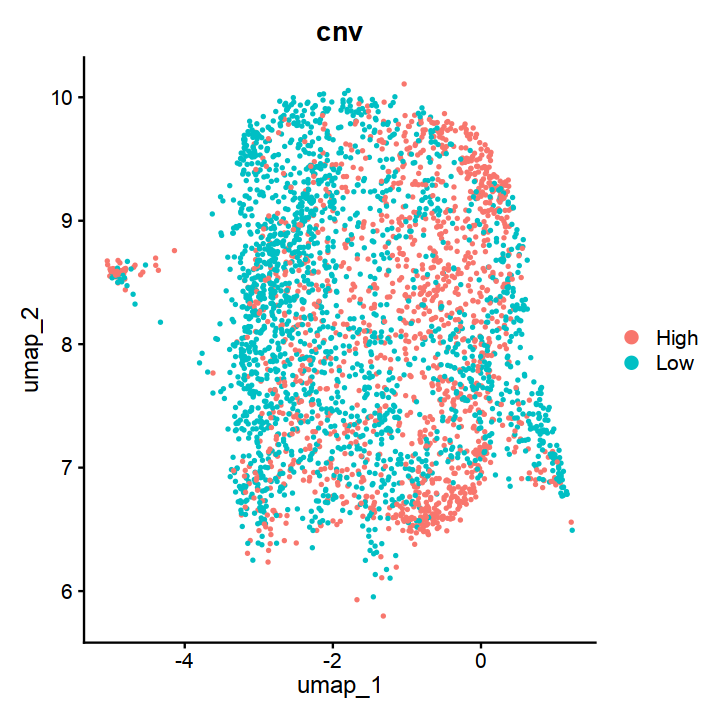

In [161]:
# Visualization
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(data_epi_high, reduction = "umap", group.by = c("cnv"))

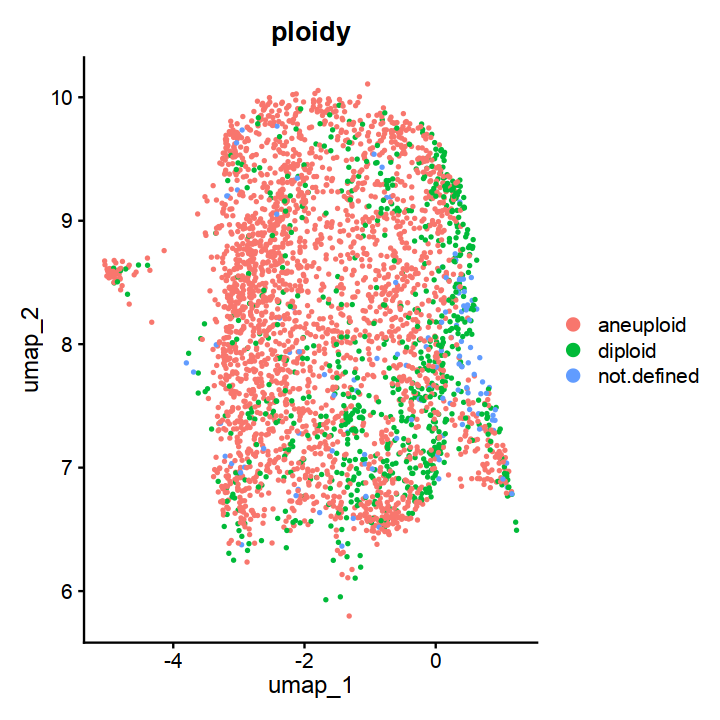

In [163]:
# Visualization
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(data_epi_high, reduction = "umap", group.by = c("ploidy"))

In [ ]:
data_epi[["RNA"]] <- split(data_epi[["RNA"]],f = data_epi$sample)

In [ ]:
data_epi <- NormalizeData(data_epi, normalization.method = "LogNormalize", 
                                           scale.factor = 10000)

In [ ]:
all.genes <- rownames(data_epi)
data_epi <- FindVariableFeatures(data_epi, selection.method = "vst", 
                                                  nfeatures = 2000)
data_epi <- ScaleData(data_epi, features = all.genes)
data_epi <- RunPCA(data_epi, features = 
                                    VariableFeatures(object = data_epi))

In [187]:
data_epi2 <- IntegrateLayers(object = data_epi, method = CCAIntegration, orig.reduction = "pca",
                        new.reduction = "integrated.cca",verbose = FALSE)

In [188]:
# re-join layers after integration
data_epi2[["RNA"]] <- JoinLayers(data_epi2[["RNA"]])

In [ ]:
data_epi2 <- FindNeighbors(data_epi2, dims = 1:30,reduction = "integrated.cca")

In [ ]:
data_epi2 <- FindClusters(data_epi2, resolution = 0.5)

In [ ]:
data_epi2 <- RunUMAP(data_epi2, dims = 1:30,reduction = "integrated.cca")

In [214]:
data_epi2@meta.data  %>% filter(RNA_snn_res.0.5 %in% c(1,2))  %>% count(sample) -> temp

In [216]:
rownames(temp) <- temp$sample

In [219]:
temp[highnames,'group']  = 'high'

In [220]:
temp[lownames,'group']  = 'low'

In [223]:
temp

,sample,n,group
,<chr>,<int>,<chr>
SC005,SC005,110,low
SC008,SC008,180,low
SC015,SC015,303,high
SC017,SC017,341,high
SC027,SC027,81,low
SC031,SC031,174,high
SC032,SC032,157,high


In [229]:
(110+180+81)/1756

[1] 0.2112756

In [228]:
(303+341+174+157)/3375

[1] 0.2888889

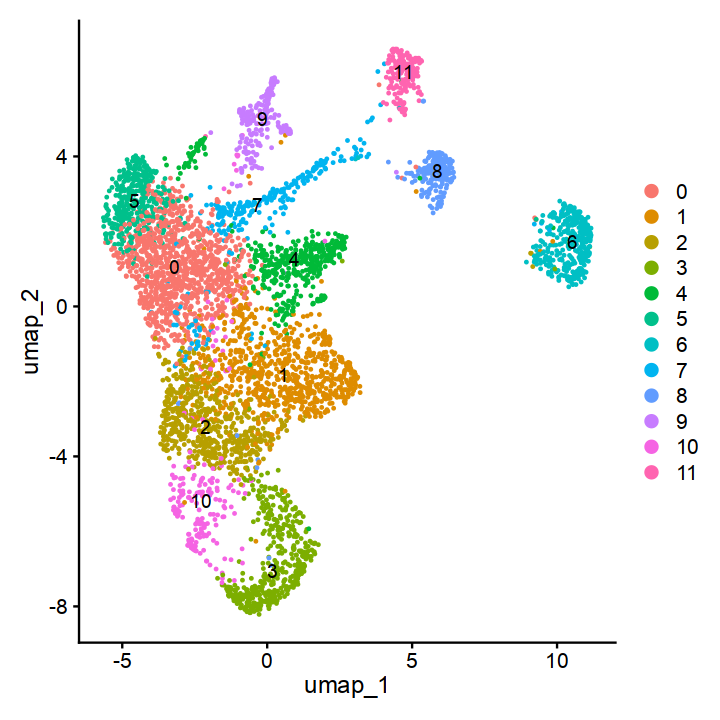

In [192]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters 
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(data_epi2, reduction = "umap", label = TRUE)

In [201]:
data_epi2@meta.data$cnv <- 'Non'
data_epi2@meta.data[high_cnv,'cnv'] <- 'High'
data_epi2@meta.data[low_cnv,'cnv'] <- 'Low'

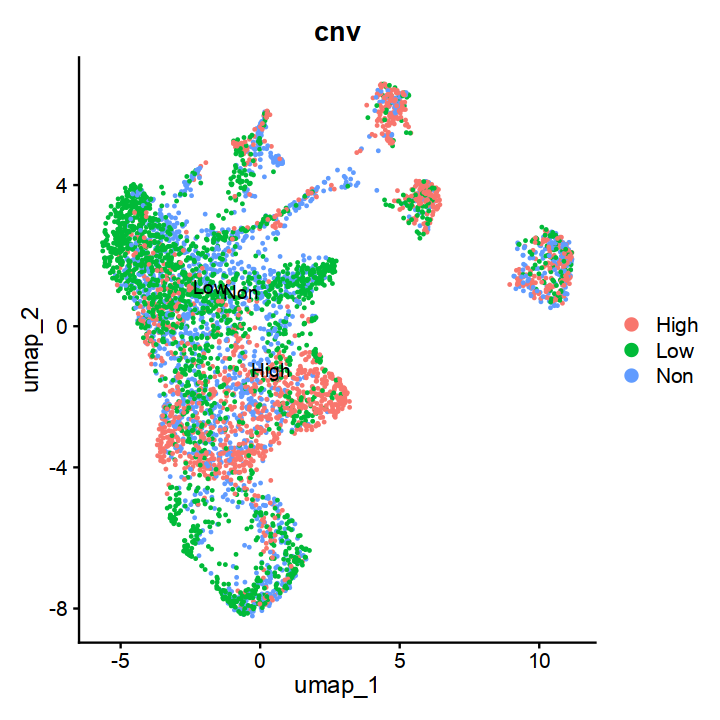

In [202]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters 
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(data_epi2, reduction = "umap", label = TRUE,group.by ="cnv" )

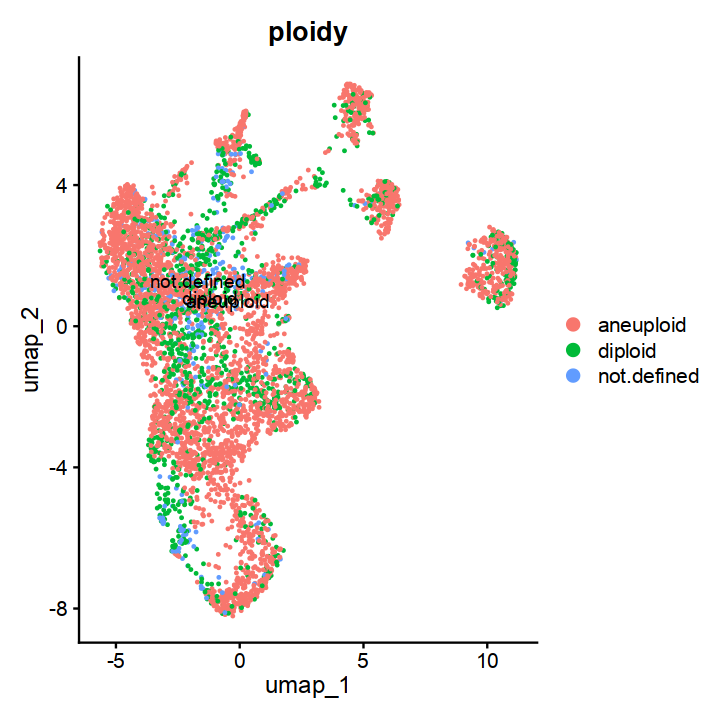

In [203]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters 
options(repr.plot.height=6,repr.plot.width=6)
DimPlot(data_epi2, reduction = "umap", label = TRUE,group.by ="ploidy" )

In [205]:
data_epi2@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,RNA_snn_res.1.2,seurat_clusters,Maincelltype,subcelltype,celltype,temp,ploidy,RNA_snn_res.0.5,cnv,Non
,<fct>,<dbl>,<dbl>,<chr>,<dbl>,<fct>,<fct>,<chr>,<fct>,<chr>,<dbl>,<chr>,<fct>,<chr>,<chr>
AAACGAAGTTACTCAG-1-SC005,SeuratProject,6821,2750,SC005,7.257000,10,3,Epithelium,Epi_tumor,Epi_tumor,0.1,aneuploid,3,Non,NA
AAAGAACGTAAGGAGA-1-SC005,SeuratProject,3441,1066,SC005,2.906132,14,8,Epithelium,Epi_tumor,Epi_tumor,0.1,diploid,8,Non,NA
AAAGAACGTGGCGCTT-1-SC005,SeuratProject,1888,972,SC005,12.235169,10,0,Epithelium,Epi_tumor,Epi_tumor,0.1,diploid,0,Non,NA
AAAGGGCAGTAGTCTC-1-SC005,SeuratProject,2239,1278,SC005,6.252791,14,0,Epithelium,Epi_tumor,Epi_tumor,0.1,diploid,0,Non,NA
AAAGGTAGTCTTCAAG-1-SC005,SeuratProject,996,732,SC005,11.044177,5,1,Epithelium,Epi_tumor,Epi_tumor,0.1,diploid,1,Non,NA
AAAGGTAGTTGCTGAT-1-SC005,SeuratProject,2145,1043,SC005,5.034965,14,8,Epithelium,Epi_tumor,Epi_tumor,0.1,diploid,8,Non,NA
AAAGGTATCAAACCCA-1-SC005,SeuratProject,996,681,SC005,6.726908,8,0,Epithelium,Epi_tumor,Epi_tumor,0.1,diploid,0,Non,NA
AAAGTGAGTTTGGCTA-1-SC005,SeuratProject,4042,1739,SC005,19.569520,14,1,Epithelium,Epi_tumor,Epi_tumor,0.1,aneuploid,1,Non,NA
AACAAAGAGGAAACGA-1-SC005,SeuratProject,8977,3220,SC005,10.092459,10,6,Epithelium,Epi_tumor,Epi_tumor,0.1,aneuploid,6,Non,NA


In [ ]:
options(repr.plot.height=10,repr.plot.width=10)
FeaturePlot(data_epi_high2, features = c("ERBB2","IGFBP2",'KRT8','EPCAM','CLDN3',"METTL7A"),  
             cols = c("grey","red"), reduction = "umap")

In [ ]:
Idents(data_epi_high2) <- 'cnv'

In [ ]:
# find markers for every cluster compared to all remaining cells, report only the positive ones
data_epi_high2.markers <- FindAllMarkers(data_epi_high2, only.pos = TRUE)

In [ ]:
data_epi_high2.markers  %>%  filter(cluster=='High')   %>% mutate(diff = (pct.1-pct.2))  %>% 
    arrange(desc(diff))